In [1]:
import warnings
from pathlib import Path
from shutil import rmtree
from json import dumps
from typing import Literal
from pickle import Pickler
from gzip import open as gz_open
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder, minmax_scale
from sklearn.compose import make_column_transformer
from sklearn.compose import make_column_selector


RANDOM_STATE = 12345

# Data

In [2]:
def get_sampling_strategy(y):
    class_names, counts = np.unique(y, return_counts=True)
    minority = int(counts.min())
    if len(class_names) < 3:
        target_size = min(minority, 5000)
        return {cls_name: target_size for cls_name in class_names}
    if len(class_names) == 8:
        return {cls_name: minority for cls_name in class_names}
    return {
        cls_name: min(int(counts[i]), 50 * minority)
        for i, cls_name in enumerate(class_names)
    }


def get_class_weight(y):
    sample_strategy = get_sampling_strategy(y)
    num_classes = len(sample_strategy)
    total_samples = sum(sample_strategy.values())
    return {
        cls_name: round(total_samples / (num_classes * count), 2)
        for cls_name, count in sample_strategy.items()
    }


def get_param_grid(num_classes):
    param_grid = {
        "model__criterion": ["gini", "entropy"],
        "model__max_features": [0.25, 0.5],
        "model__min_samples_leaf": [3, 5, 7],
    }
    if num_classes < 3:
        param_grid["model__n_estimators"] = [100, 150, 200]
        param_grid["model__max_leaf_nodes"] = [300, 600, 900]
    elif num_classes == 8:
        param_grid["model__n_estimators"] = [75, 100, 125]
        param_grid["model__max_leaf_nodes"] = [600, 900, 1200]
    else:
        param_grid["model__n_estimators"] = [30, 40, 50]
        param_grid["model__max_leaf_nodes"] = [1200, 1800, 2400]
        param_grid["model__max_features"] = [0.4, 0.6]
    return param_grid


def prepare_experiment(
    which: Literal["full", "iot", "control", "infra"],
    target: Literal["binary", "grouped", "all"],
    overwrite: bool = False,
):
    experiment = {}
    dataset_path = Path("../datasense/dataset/")
    for split in ["train", "test"]:
        split_data = dataset_path / f"datasense_{which}_{split}_1sec.parquet"
        split_data = pd.read_parquet(split_data)
        if target == "binary":
            y_split = split_data["label1"]
        elif target == "grouped":
            y_split = split_data["label2"]
        else:
            y_split = split_data["label4"]
        experiment[split] = (split_data, y_split)
    experiment["num_classes"] = experiment["train"][1].nunique()
    number_selector = make_column_selector(dtype_include="number")
    bool_selector = make_column_selector(dtype_include="bool")
    if which == "full":
        experiment["transformers"] = make_column_transformer(
            ("passthrough", number_selector),
            ("passthrough", bool_selector),
            (OneHotEncoder(sparse_output=False), ["device_type"]),
            remainder="drop",
            verbose_feature_names_out=False,
        )
    else:
        experiment["transformers"] = make_column_transformer(
            ("passthrough", number_selector),
            ("passthrough", bool_selector),
            remainder="drop",
            verbose_feature_names_out=False,
        )
    results_dir = Path("results")
    results_dir /= f"random_forest_{which}_{target}"
    if results_dir.is_dir():
        if overwrite:
            rmtree(results_dir, ignore_errors=True)
        else:
            raise RuntimeError("Experiment already executed and overwrite set to False")
    results_dir.mkdir(exist_ok=True, parents=True)
    cache_dir = results_dir / ".cache"
    cache_dir.mkdir()
    experiment["results_dir"] = results_dir
    experiment["cache_dir"] = str(cache_dir)
    return experiment

# Experiment

In [3]:
experiment = prepare_experiment(which="full", target="all", overwrite=True)

X_train, y_train = experiment["train"]
X_test, y_test = experiment["test"]
results_dir = experiment["results_dir"]
cache_dir = experiment["cache_dir"]

## Training pipe

In [4]:
model = BalancedRandomForestClassifier(
    bootstrap=False,
    replacement=False,
    sampling_strategy=get_sampling_strategy,
    class_weight=get_class_weight(y_train),
    random_state=RANDOM_STATE,
)

In [5]:
train_pipe = Pipeline(
    steps=[
        ("transformer", experiment["transformers"]),
        ("model", model),
    ],
    memory=cache_dir,
    verbose=False,
)

## Grid seach cross-validation

In [6]:
param_grid = get_param_grid(experiment["num_classes"])

In [7]:
grid = GridSearchCV(
    estimator=train_pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    n_jobs=4,
    refit=True,
    cv=4,
    verbose=3,
    return_train_score=True,
)

with warnings.catch_warnings():
    warnings.filterwarnings(action="ignore", message=r"^A worker stopped while")
    grid.fit(X_train, y_train)

trained_pipe = grid.best_estimator_
trained_model = trained_pipe["model"]

Fitting 4 folds for each of 108 candidates, totalling 432 fits
[CV 4/4] END model__criterion=gini, model__max_features=0.4, model__max_leaf_nodes=1200, model__min_samples_leaf=3, model__n_estimators=30;, score=(train=0.737, test=0.681) total time=  26.0s
[CV 1/4] END model__criterion=gini, model__max_features=0.4, model__max_leaf_nodes=1200, model__min_samples_leaf=3, model__n_estimators=30;, score=(train=0.737, test=0.675) total time=  28.3s
[CV 3/4] END model__criterion=gini, model__max_features=0.4, model__max_leaf_nodes=1200, model__min_samples_leaf=3, model__n_estimators=30;, score=(train=0.742, test=0.684) total time=  28.4s
[CV 2/4] END model__criterion=gini, model__max_features=0.4, model__max_leaf_nodes=1200, model__min_samples_leaf=3, model__n_estimators=30;, score=(train=0.745, test=0.689) total time=  28.9s
[CV 4/4] END model__criterion=gini, model__max_features=0.4, model__max_leaf_nodes=1200, model__min_samples_leaf=3, model__n_estimators=40;, score=(train=0.739, test=0.6

## Cross-validation results

In [8]:
cv_results = pd.DataFrame(grid.cv_results_)
cv_results.sort_values(by="rank_test_score", inplace=True)
cv_results.to_csv(results_dir / "train_cv_results.csv", index=False)

cv_results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__criterion,param_model__max_features,param_model__max_leaf_nodes,param_model__min_samples_leaf,param_model__n_estimators,params,...,split3_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,mean_train_score,std_train_score
65,50.382634,0.715198,1.458754,0.351470,entropy,0.4,1800,3,50,"{'model__criterion': 'entropy', 'model__max_fe...",...,0.682145,0.685936,0.003961,1,0.759717,0.762857,0.760367,0.754879,0.759455,0.002890
74,51.288868,0.949563,1.120827,0.576584,entropy,0.4,2400,3,50,"{'model__criterion': 'entropy', 'model__max_fe...",...,0.681799,0.685818,0.004552,2,0.766021,0.772527,0.768417,0.763724,0.767672,0.003257
72,31.212312,0.882824,0.874674,0.332493,entropy,0.4,2400,3,30,"{'model__criterion': 'entropy', 'model__max_fe...",...,0.681784,0.685677,0.004651,3,0.762101,0.768489,0.765329,0.760138,0.764014,0.003180
73,40.838485,0.104686,0.873130,0.134732,entropy,0.4,2400,3,40,"{'model__criterion': 'entropy', 'model__max_fe...",...,0.680963,0.685496,0.003887,4,0.764721,0.770618,0.767283,0.762819,0.766360,0.002924
56,51.852034,0.856287,1.492888,0.459480,entropy,0.4,1200,3,50,"{'model__criterion': 'entropy', 'model__max_fe...",...,0.681651,0.685403,0.002911,5,0.744946,0.744073,0.744576,0.737115,0.742677,0.003226
63,30.563762,0.776755,1.150225,0.372451,entropy,0.4,1800,3,30,"{'model__criterion': 'entropy', 'model__max_fe...",...,0.681642,0.685211,0.003832,6,0.755902,0.760461,0.756712,0.752672,0.756437,0.002772
64,40.490975,0.515819,1.238830,0.263060,entropy,0.4,1800,3,40,"{'model__criterion': 'entropy', 'model__max_fe...",...,0.680708,0.685143,0.003931,7,0.757628,0.761834,0.758729,0.754372,0.758141,0.002667
54,31.910389,1.001597,0.867942,0.199048,entropy,0.4,1200,3,30,"{'model__criterion': 'entropy', 'model__max_fe...",...,0.680756,0.685031,0.003865,8,0.742094,0.742130,0.742141,0.735462,0.740457,0.002884
55,41.153609,0.676068,1.236813,0.457212,entropy,0.4,1200,3,40,"{'model__criterion': 'entropy', 'model__max_fe...",...,0.680898,0.684975,0.003367,9,0.743226,0.742367,0.743665,0.737054,0.741578,0.002653
2,38.596511,1.623658,1.977969,0.667495,gini,0.4,1200,3,50,"{'model__criterion': 'gini', 'model__max_featu...",...,0.679790,0.684645,0.005713,10,0.741460,0.746430,0.745863,0.740830,0.743646,0.002519


## Feature importance

In [9]:
feature_names = trained_pipe["transformer"].get_feature_names_out()

feature_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": trained_pipe["model"].feature_importances_,
})
feature_importances.sort_values(
    by="importance", ascending=False,
    ignore_index=True, inplace=True,
)
feature_importances["importance_norm"] = minmax_scale(
    feature_importances["importance"]
)

feature_importances.to_csv(
    results_dir / "feature_importances.csv", index=False
)

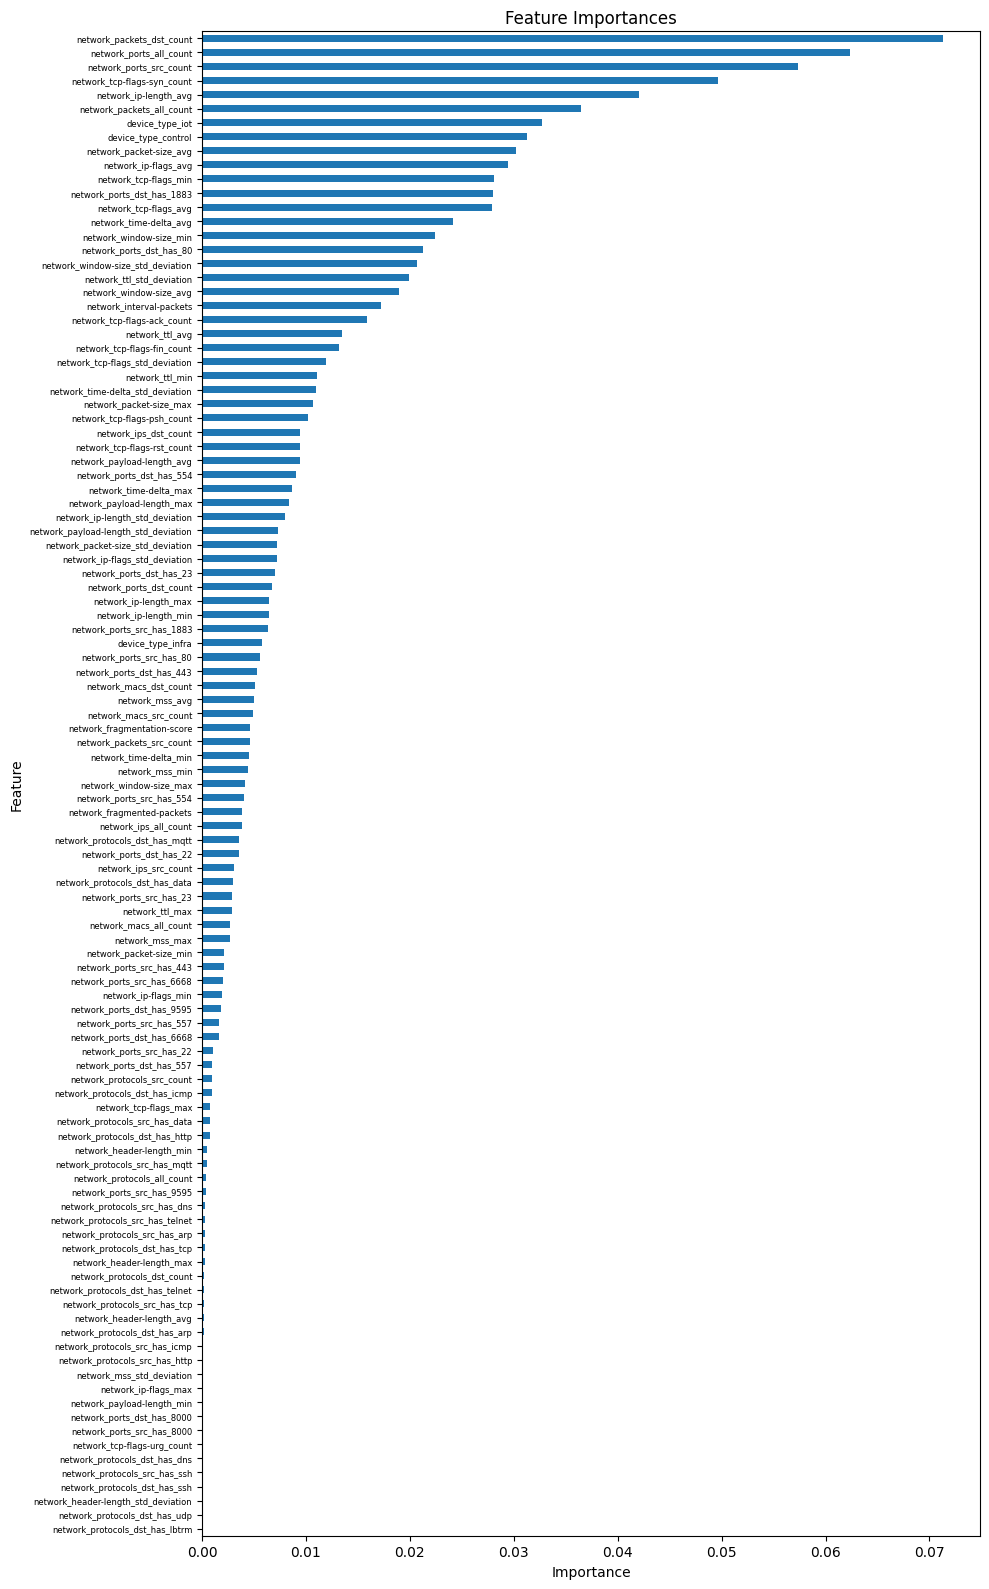

In [10]:
fig, ax = plt.subplots(figsize=(10, 16))

feature_importances["importance"].plot(kind="barh", ax=ax)

ax.invert_yaxis()
ax.set_yticks(
    ticks=range(feature_importances.shape[0]),
    labels=feature_importances["feature"],
    fontsize=6,
)
ax.set_title("Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig(results_dir / "feature_importances.png", dpi=300)
plt.show()

# Model evaluations

## Train-split evaluations

In [11]:
y_proba = trained_pipe.predict_proba(X_train)

train_results = pd.DataFrame(
    data=y_proba,
    columns=trained_pipe.classes_,
    dtype="float32",
)

train_results.to_parquet(
    results_dir / "train_predict_proba.parquet",
    index=False,
    compression="gzip",
)

## Test-split evaluations

In [12]:
y_proba = trained_pipe.predict_proba(X_test)

test_results = pd.DataFrame(
    data=y_proba,
    columns=trained_pipe.classes_,
    dtype="float32",
)

test_results.to_parquet(
    results_dir / "test_predict_proba.parquet",
    index=False,
    compression="gzip",
)

# Model summary and persistency

## Model persistency

In [13]:
trained_model.samplers_ = []
trained_model.pipelines_ = []

pipe_persist_path = results_dir / "pipe.pickle.gz"

with gz_open(pipe_persist_path, mode="wb") as pf:
    Pickler(pf, protocol=5).dump(trained_pipe)

## Model summary

In [14]:
total_n_nodes = sum(dtree.tree_.node_count for dtree in trained_model.estimators_)
total_n_leaves = sum(dtree.tree_.n_leaves for dtree in trained_model.estimators_)
total_depths = sum(dtree.tree_.max_depth for dtree in trained_model.estimators_)

model_summary = {
    "best_parameters": grid.best_params_,
    "all_parameters": trained_model.get_params(),
    "forest_structure": {
        "total_n_nodes": total_n_nodes,
        "mean_n_nodes": round(total_n_nodes / len(trained_model.estimators_), 2),
        "mean_n_leafs": round(total_n_leaves / len(trained_model.estimators_), 2),
        "mean_depth": round(total_depths / len(trained_model.estimators_), 2),
    }
}

model_summary = dumps(model_summary, indent=2, default=str)
(results_dir / "model_summary.json").write_text(model_summary)
print("MODEL SUMMARY:", model_summary, sep="\n")

MODEL SUMMARY:
{
  "best_parameters": {
    "model__criterion": "entropy",
    "model__max_features": 0.4,
    "model__max_leaf_nodes": 1800,
    "model__min_samples_leaf": 3,
    "model__n_estimators": 50
  },
  "all_parameters": {
    "bootstrap": false,
    "ccp_alpha": 0.0,
    "class_weight": {
      "benign": 0.49,
      "bruteforce_dictionary-ssh": 0.77,
      "bruteforce_dictionary-telnet": 0.83,
      "ddos_ack-frag-flood-port-1883": 0.81,
      "ddos_ack-frag-flood-port-80": 1.11,
      "ddos_connect-flood": 12.19,
      "ddos_http-flood-port-1883": 0.81,
      "ddos_http-flood-port-80": 1.11,
      "ddos_icmp-flood": 0.49,
      "ddos_icmp-frag-flood": 0.49,
      "ddos_mqtt-publish-flood": 12.19,
      "ddos_push-ack-flood-port-1883": 0.81,
      "ddos_push-ack-flood-port-80": 1.1,
      "ddos_rst-fin-flood-port-1883": 0.81,
      "ddos_rst-fin-flood-port-80": 1.1,
      "ddos_slowloris-port-1883": 12.19,
      "ddos_slowloris-port-554": 12.19,
      "ddos_slowloris-port-80